# Data Exploration (Task 1)

In [60]:
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))
from functions import stratified_split, xyz

seed=42

## 1.1 Data Loading & Spliting

In [11]:
data_dir = project_root/'data'
dev_df = pd.read_csv(f'{data_dir}/development_data.csv')
test_df = pd.read_csv(f'{data_dir}/evaluation_data.csv')

train_df, val_df = stratified_split(dev_df, seed=seed)

## 1.2 Preprocessing 

In [14]:
cpg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]).set_output(transform="pandas")

In [16]:
# Train Set
X_train, y_train, z_train = xyz(train_df, cpg_pipe, is_train=True)
X_all_train = np.hstack([z_train.values, X_train])

# Validate Set
X_val, y_val, z_val = xyz(val_df, cpg_pipe)
X_all_val = np.hstack([z_val.values, X_val])

# Test Set (LOCKED)
X_test, y_test, z_test = xyz(test_df, cpg_pipe)
X_all_test = np.hstack([z_test.values, X_test])

# Feature Sets
feature_sets = {
    "Metadata": (z_train.values, z_val.values),
    "CpG": (X_train, X_val),
    "Combined": (X_all_train, X_all_val)
}

In [71]:
# pack processed data to use on model analysis notebook
processed_data = {
    'X_train': X_train,
    'y_train': y_train,
    'z_train': z_train,
    'X_all_train': X_all_train,
    'X_val': X_val,
    'y_val': y_val,
    'z_val': z_val,
    'X_all_val': X_all_val,
    'X_test': X_test,
    'y_test': y_test,
    'z_test': z_test,
    'X_all_test': X_all_test,
    'feature_sets': feature_sets
}

_ = joblib.dump(processed_data, f'{project_root/'data'}/processed_data.pkl')

## 1.3  Exploratory analysis 

In [19]:
n = len(dev_df)
males = dev_df['sex'].value_counts().iloc[0]
males_pct = males / n * 100

stats = {
    "n (Train/Val)": f"{n} ({len(train_df)} / {len(val_df)})",
    "NaNs": f'{dev_df.isnull().sum().sum()} ({train_df.isnull().sum().sum()} / {val_df.isnull().sum().sum()})',
    "Age (Mean ± STD)": f"{dev_df['age'].mean():.3f} ± {dev_df['age'].std():.3f}",
    "Age (Range)": f"[{dev_df['age'].min():.0f} - {dev_df['age'].max():.0f}]",
    "Sex (M)": f"{males} ({males_pct:.2f}%)",
    "Sex (F)": f"{n - males} ({(100 - males_pct):.2f}%)",
}

display(pd.DataFrame([stats], index=["Development Set"]))

,n (Train/Val),NaNs,Age (Mean ± STD),Age (Range),Sex (M),Sex (F)
Development Set,456 (364 / 92),13712 (10992 / 2720),64.452 ± 14.632,[19 - 101],232 (50.88%),224 (49.12%)


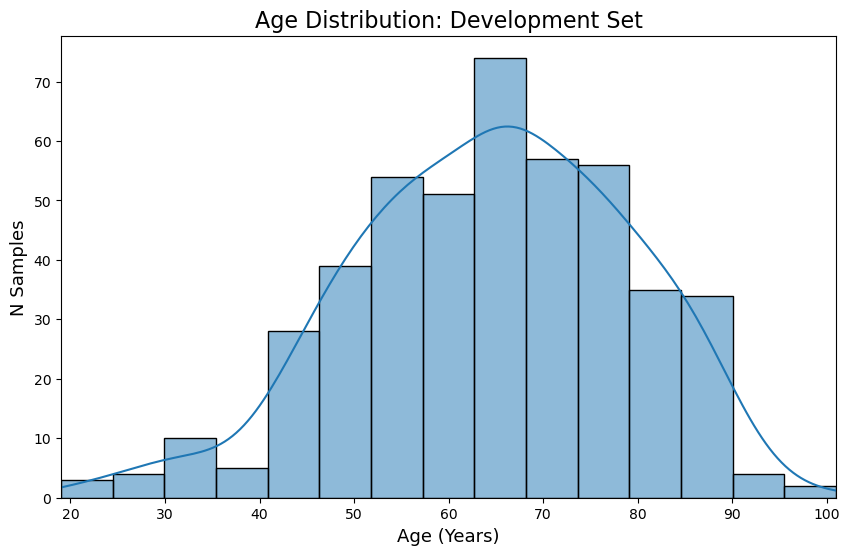

In [51]:
plt.figure(figsize=(10, 6))

sns.histplot(dev_df['age'],
             kde=1,)

plt.title('Age Distribution: Development Set', fontsize=16)
plt.xlabel('Age (Years)', fontsize=13)
plt.ylabel('N Samples', fontsize=13)

plt.xlim(19, 101)

plt.savefig(f'{project_root/'figures'}/age_distribution.png', dpi=300, bbox_inches='tight')

plt.show()